In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

topvfcs = range(1,13)

df_v = pd.read_excel('../data/Supplementary_Data_1_vOTU_metadata.xlsx', usecols=['votu_id','VFC','num_DGRs'])

df_vc = pd.read_excel('../data/Supplementary_Data_3_VFC_metadata.xlsx', usecols=['VFC','VC_size','perc_has_DGR','perc_has_AMG','perc_has_defense','perc_has_antidefense'])
df_vc = df_vc[df_vc.VC_size > 1] # non-singleton VFCs
df_topvfc = df_vc[df_vc.VFC.isin(topvfcs)]

### Supplementary Fig. 28A: several of the top VFCs have high DGR prevalence

In [2]:
# outlier VFCs in DGR prevalence

dgr_prev_median = df_vc.perc_has_DGR.median()
dgr_prev_Q1 = df_vc.perc_has_DGR.quantile(0.25)
dgr_prev_Q3 = df_vc.perc_has_DGR.quantile(0.75)

dgr_prev_thresh = dgr_prev_median + 2*(dgr_prev_Q3 - dgr_prev_Q1)

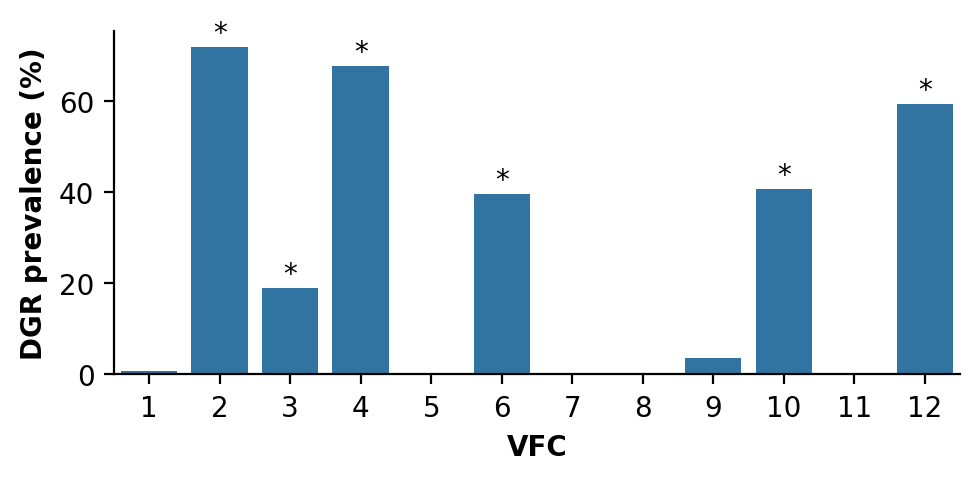

In [3]:
fig, ax = plt.subplots(figsize=(5,2.5), dpi=200)

sns.barplot(data=df_topvfc, x='VFC', y='perc_has_DGR')

# Annotate outlier VFCs
for p, perc in zip(ax.patches, df_topvfc['perc_has_DGR']):
    if perc > dgr_prev_thresh:
        ax.text(
            p.get_x() + p.get_width()/2,
            perc,
            "*",
            ha='center',
            va='bottom',
            fontsize=10,
            color='black'
        )

plt.xlabel('VFC', weight='bold')
plt.ylabel('DGR prevalence (%)', weight='bold')
plt.xticks(range(len(topvfcs)), topvfcs)

sns.despine()
plt.tight_layout()

### Supplementary Fig. 28B: genes containing DGR variable regions have high pN/pS
pN/pS of genes with at least 1 SNP are plotted.

In [4]:
df_dgr = pd.read_excel('../data/Supplementary_Data_9_DGR_defense_anti-defense_and_AMG_annotations.xlsx', sheet_name='DGRs', usecols=['votu_id','variable_coordinates'])
df_dgr[['variable_start','variable_end']] = df_dgr['variable_coordinates'].str.split('-', expand=True).astype(int)

df_pnps = pd.read_csv('../data/Supplementary_Data_10_pN-pS_analysis.tsv', sep='\t', usecols=['gene','CHROM','sample_id','num_SNP_pos','pNpS']).rename(columns={'CHROM': 'votu_id'})
df_g = pd.read_csv('../data/Supplementary_Data_4_gene_annotations_of_SPMP_and_reference_vOTUs.tsv', sep='\t', usecols=['gene','start','end','annotation_description'])
df_pnps = df_pnps.merge(df_g, on='gene', how='left')

df1 = df_pnps.merge(df_dgr, on='votu_id', how='left')

Find genes overlapping with DGR variable regions

In [5]:
def regions_overlap(row, start1, end1, start2, end2):
    return max(row[start1], row[start2]) <= min(row[end1], row[end2])

df1['vr_overlaps_gene'] = df1.apply(regions_overlap, axis=1, args=('variable_start','variable_end','start','end'))

In [6]:
df1 = df1.merge(df_v[['votu_id', 'VFC']], on='votu_id', how='left')
df1_topvfcs = df1[df1.VFC.isin(topvfcs)]
df1_topvfcs_1snp = df1_topvfcs[df1_topvfcs.num_SNP_pos > 0] # plot only genes with at least 1 SNP

"Genes containing DGR variable regions show significantly higher pN/pS ratios (**median 0.9 vs 0.3**; two-sided Mann-Whitney U test **p-value<10<sup>-6</sup>**)."

In [7]:
from scipy.stats import mannwhitneyu

group_true = df1_topvfcs_1snp[df1_topvfcs_1snp['vr_overlaps_gene'] == True]['pNpS']
group_false = df1_topvfcs_1snp[df1_topvfcs_1snp['vr_overlaps_gene'] == False]['pNpS']

stat, pvalue = mannwhitneyu(group_true, group_false, alternative='two-sided')
print(f'Median pN/pS of genes overlapping with DGR variable region = {np.median(group_true):.3f}, not overlapping = {np.median(group_false):.3f}, two-sided Mann-Whitney p-value = {pvalue:.0e}')

Median pN/pS of genes overlapping with DGR variable region = 0.938, not overlapping = 0.315, two-sided Mann-Whitney p-value = 7e-48


C:\Users\chenhr\AppData\Local\Temp\ipykernel_45388\958667178.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\chenhr\AppData\Local\Temp\ipykernel_45388\958667178.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['no', 'yes'])


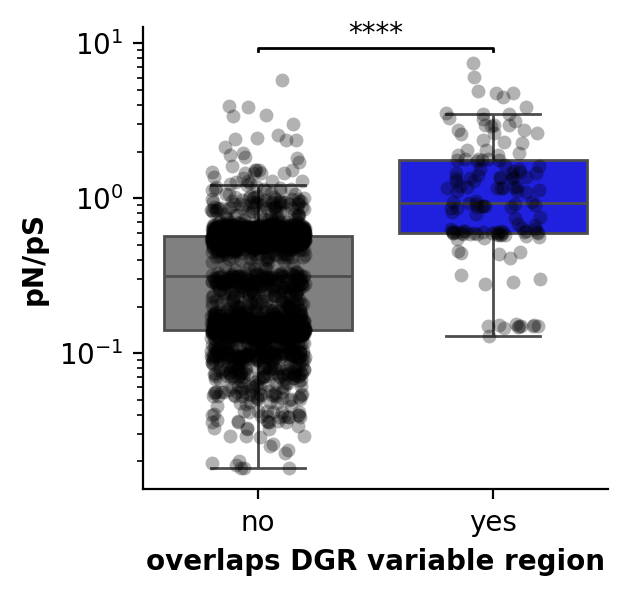

In [8]:
fig, ax = plt.subplots(figsize=(3,3), dpi=200)

sns.boxplot(
    data=df1_topvfcs_1snp,
    x='vr_overlaps_gene',
    y='pNpS',
    showfliers=False,
    palette={'True': 'blue', 'False': 'grey'},
    ax=ax
)

sns.stripplot(
    data=df1_topvfcs_1snp,
    x='vr_overlaps_gene',
    y='pNpS',
    color='black',
    alpha=0.3,
    jitter=0.2,
    ax=ax
)

ax.set_yscale('log')

ax.set_xlabel("overlaps DGR variable region", fontweight='bold')
ax.set_ylabel("pN/pS", fontweight='bold')
ax.set_xticklabels(['no', 'yes'])

# annotate significance
if pvalue < 0.0001:
    sig = '****'
elif pvalue < 0.001:
    sig = '***'
elif pvalue < 0.01:
    sig = '**'
elif pvalue < 0.05:
    sig = '*'
else:
    sig = 'ns'

y_max = df1_topvfcs_1snp['pNpS'].max()
y, h, col = y_max * 1.2, y_max * 0.05, 'black'  # y location, height of bar
ax.plot([0, 0, 1, 1], [y, y+h, y+h, y], lw=1, c=col)
ax.text(0.5, y+h*1.2, sig, ha='center', va='bottom', color=col, fontsize=10)

sns.despine()
plt.show()

### Supplementary Fig. 28C: annotations of genes containing DGR variable regions
All genes (not only those with at least 1 SNP).

In [9]:
df1_topvfcs[df1_topvfcs.vr_overlaps_gene == True][['gene','annotation_description']].drop_duplicates().annotation_description.value_counts()

annotation_description
Putative phage holin Dp-1                         14
Phage-related tail fibre protein                  10
Bacteriophage lambda head decoration protein D     9
Phage terminase, large subunit GpA                 9
CotH kinase protein                                9
Phage terminase, small subunit                     9
BppU N-terminal domain                             5
Phage-related minor tail protein                   1
Name: count, dtype: int64

### Supplementary Fig. 30AB: defense and anti-defense systems in the top VFCs

In [10]:
# outlier VFCs in defense system prevalence

def_prev_med = df_vc.perc_has_defense.median()
def_prev_Q1 = df_vc.perc_has_defense.quantile(0.25)
def_prev_Q3 = df_vc.perc_has_defense.quantile(0.75)

def_prev_thresh = def_prev_med + 2*(def_prev_Q3 - def_prev_Q1)

vfcs_highdef = df_vc[df_vc.perc_has_defense > def_prev_thresh].VFC.tolist()

In [11]:
# outlier VFCs in anti-defense system prevalence

adef_prev_med = df_vc.perc_has_antidefense.median()
adef_prev_Q1 = df_vc.perc_has_antidefense.quantile(0.25)
adef_prev_Q3 = df_vc.perc_has_antidefense.quantile(0.75)

adef_prev_thresh = adef_prev_med + 2*(adef_prev_Q3 - adef_prev_Q1)

vfcs_highadef = df_vc[df_vc.perc_has_antidefense > adef_prev_thresh].VFC.tolist()

In [ ]:
# Parse defense systems (not genes)
df_defense = pd.read_excel('../data/Supplementary_Data_9_DGR_defense_anti-defense_and_AMG_annotations.xlsx', sheet_name='Defense, anti-defense', usecols=['votu_id','sys_id','type','activity']).drop_duplicates()
df_defense = df_defense.merge(df_v[['votu_id', 'VFC']], on='votu_id', how='left')
df_defense_topvfcs = df_defense[df_defense.VFC.isin(topvfcs)]

df_df = df_defense_topvfcs[df_defense_topvfcs['activity'] == 'Defense'].copy()
df_adf = df_defense_topvfcs[df_defense_topvfcs['activity'] == 'Antidefense'].copy()

# Top 10 defense systems
top_defense_systems = df_df['type'].value_counts().head(10).index
df_df['system_group'] = df_df['type'].apply(
    lambda x: x if x in top_defense_systems else 'Others'
)

# Top 10 anti-defense systems
top_antidefense_systems = df_adf['type'].value_counts().head(10).index
df_adf['system_group'] = df_adf['type'].apply(
    lambda x: x if x in top_antidefense_systems else 'Others'
)

df_df_grouped = df_df.groupby(['votu_id', 'system_group']).size().unstack(fill_value=0)
df_adf_grouped = df_adf.groupby(['votu_id', 'system_group']).size().unstack(fill_value=0)

df_df_final = df_df_grouped.clip(upper=1)
df_adf_final = df_adf_grouped.clip(upper=1)

df_df_merged = df_v.loc[df_v.VFC.isin(topvfcs), ['votu_id', 'VFC']].merge(df_df_final, on='votu_id', how='left')
df_adf_merged = df_v.loc[df_v.VFC.isin(topvfcs), ['votu_id', 'VFC']].merge(df_adf_final, on='votu_id', how='left')

df_df_merged = df_df_merged.fillna(0)
df_adf_merged = df_adf_merged.fillna(0)

df_cols_df = (list(top_defense_systems) + ['Others'])[::-1]
df_cols_adf = (list(top_antidefense_systems))[::-1] # no "Others"

df_df_pct = df_df_merged.groupby('VFC')[df_cols_df].mean() * 100
df_adf_pct = df_adf_merged.groupby('VFC')[df_cols_adf].mean() * 100

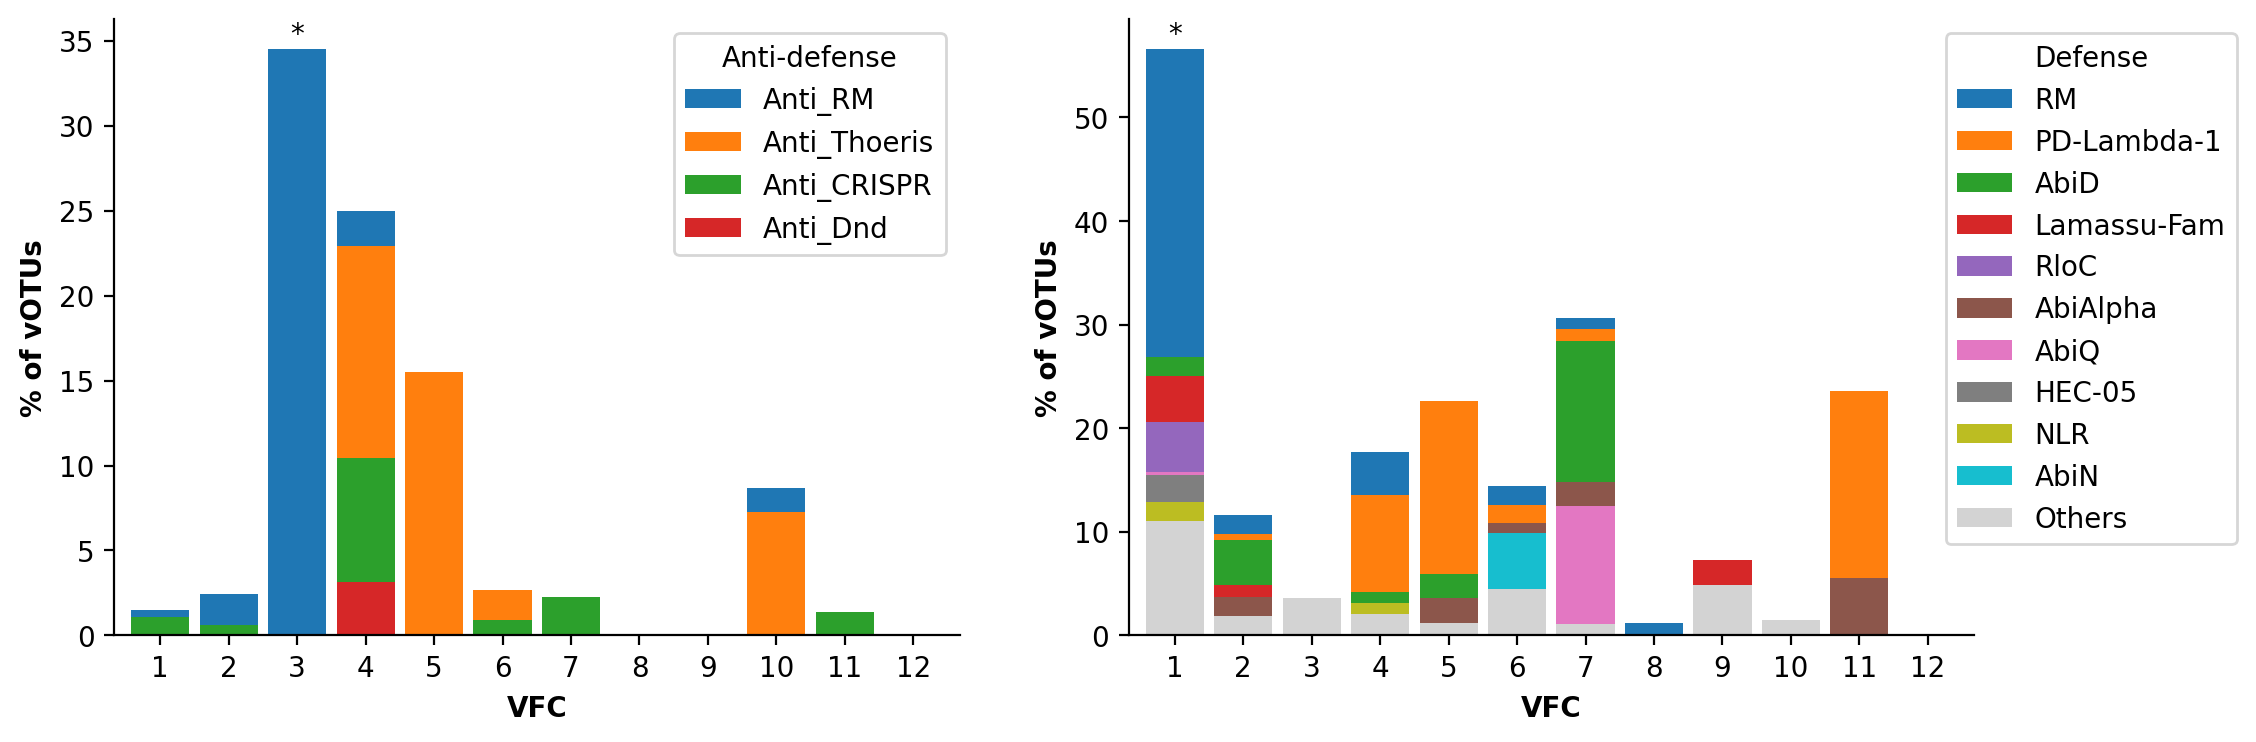

In [13]:
colors_df = ([f'C{i}' for i in range(len(df_cols_df)-1)] + ['lightgrey'])[::-1]
colors_adf = ([f'C{i}' for i in range(len(df_cols_adf))])[::-1] # no "Others"

fig, ax = plt.subplots(1, 2, figsize=(12, 4), dpi=200)

# ---------------------------
# Plot anti-defense system prevalence
# ---------------------------
df_adf_pct.plot(
    kind='bar',
    stacked=True,
    width=0.85,
    color=colors_adf,
    ax=ax[0]
)

# Annotate outlier VFCs
for i, vfc in enumerate(topvfcs):
    if vfc in vfcs_highadef:
        top = df_adf_pct.iloc[i].sum()
        ax[0].text(
            i,
            top,
            "*",
            ha='center',
            va='bottom',
            fontsize=10,
            color='black'
        )

ax[0].set_xlabel("VFC", fontweight='bold')
ax[0].set_ylabel("% of vOTUs", fontweight='bold')
ax[0].set_xticks(range(len(topvfcs)))
ax[0].set_xticklabels(topvfcs, rotation=0)
handles, labels = ax[0].get_legend_handles_labels()
ax[0].legend(handles[::-1], labels[::-1], title="Anti-defense", bbox_to_anchor=(1, 1), loc="upper right")

# ---------------------------
# Plot defense system prevalence
# ---------------------------
df_df_pct.plot(
    kind='bar',
    stacked=True,
    width=0.85,
    color=colors_df,
    ax=ax[1]
)

# Annotate outlier VFCs
for i, vfc in enumerate(topvfcs):
    if vfc in vfcs_highdef:
        top = df_df_pct.iloc[i].sum()
        ax[1].text(
            i,
            top,
            "*",
            ha='center',
            va='bottom',
            fontsize=10,
            color='black'
        )

ax[1].set_xlabel("VFC", fontweight='bold')
ax[1].set_ylabel("% of vOTUs", fontweight='bold')
ax[1].set_xticks(range(len(topvfcs)))
ax[1].set_xticklabels(topvfcs, rotation=0)
handles, labels = ax[1].get_legend_handles_labels()
ax[1].legend(handles[::-1], labels[::-1], title="Defense", bbox_to_anchor=(0.95, 1), loc="upper left")

sns.despine()

### Supplementary Fig. 31A: auxiliary metabolic genes (AMGs) in the top VFCs

In [ ]:
# outlier VFCs in AMG prevalence

amg_prev_med = df_vc.perc_has_AMG.median()
amg_prev_Q1 = df_vc.perc_has_AMG.quantile(0.25)
amg_prev_Q3 = df_vc.perc_has_AMG.quantile(0.75)

amg_prev_thresh = amg_prev_med + 2*(amg_prev_Q3 - amg_prev_Q1)

vfcs_highamg = df_vc[df_vc.perc_has_AMG > amg_prev_thresh].VFC.tolist()

In [15]:
df_amg = pd.read_excel('../data/Supplementary_Data_9_DGR_defense_anti-defense_and_AMG_annotations.xlsx', sheet_name='AMGs', usecols=['votu_id','gene','gene_description']).drop_duplicates('gene')
df_amg = df_amg.merge(df_v[['votu_id', 'VFC']], on='votu_id', how='left')
df_amg_topvfcs = df_amg[df_amg.VFC.isin(topvfcs)].copy()

# remove EC IDs from gene descriptions
df_amg_topvfcs['gene_description1'] = df_amg_topvfcs['gene_description'].str.replace(r"\s*\[.*$", "", regex=True)

# shorten some very long descriptions
df_amg_topvfcs['gene_description1'] = (
    df_amg_topvfcs['gene_description1']
    .replace('Catlytic type: Serine; hydrolyses Asp-Xaa dipeptides in which Xaa is not Glu, Asn or Gln; nutritional function in bacteria', 'Catlytic type: Serine')
    .replace("GH13 alpha-amylase (EC 3.2.1.1); pullulanase (EC 3.2.1.41); cyclomaltodextrin glucanotransferase (EC 2.4.1.19); cyclomaltodextrinase (EC 3.2.1.54); trehalose-6-phosphate hydrolase (EC 3.2.1.93); oligo-alpha-glucosidase (EC 3.2.1.10); maltogenic amylase (EC 3.2.1.133); neopullulanase (EC 3.2.1.135); alpha-glucosidase (EC 3.2.1.20); maltotetraose-forming alpha-amylase (EC 3.2.1.60); isoamylase (EC 3.2.1.68); glucodextranase (EC 3.2.1.70); maltohexaose-forming alpha-amylase (EC 3.2.1.98); maltotriose-forming alpha-amylase (EC 3.2.1.116); branching enzyme (EC 2.4.1.18); trehalose synthase (EC 5.4.99.16); 4-alpha-glucanotransferase (EC 2.4.1.25); maltopentaose-forming alpha-amylase (EC 3.2.1.-) ; amylosucrase (EC 2.4.1.4) ; sucrose phosphorylase (EC 2.4.1.7); malto-oligosyltrehalose trehalohydrolase (EC 3.2.1.141); isomaltulose synthase (EC 5.4.99.11); malto-oligosyltrehalose synthase (EC 5.4.99.15); amylo-alpha-1,6-glucosidase (EC 3.2.1.33); alpha-1,4-glucan: phosphate alpha-maltosyltransferase (EC 2.4.99.16); 6'-P-sucrose phosphorylase (EC 2.4.1.-); amino acid transporter", 'GH13 alpha-amylase')
    .replace("Catlytic type: Aspartate; residues with large hydrophobic sidechains on either side of the scissile bond, but several members have more restricted specificities that allow protein-processing functions (see additional Info); The amino acid sequences show signal peptides and propeptides except for bacterial homologues which also lack disulfide bridges and are probably cytoplasmic (Rawlings & Bateman, 2009). Many three-dimensional structures have been described. The catalytic site is located between the two lobes of the molecules, and a 'flap' structure containing a conserved Tyr residue controls specificity (James, 2004; Hong & Tang, 2004). Several of the peptidases are glycosylated (e.g. cathepsin D, A01.009) and a few are membrane-bound (memapsin-1 and memapsin-2, A01.041 and A01.004, respectively). Some family A1 peptidases from plants (e.g. phytepsin, A01.020) contain inserted saposin-like sequences, and the effects of these on enzymatic activity have been investigated (Payie et al., 2003). The secreted proteins in subfamily A usually have three conserved disulfide bridges, whereas in subfamily B there are six, and the unusual stability of nepenthesin (A01.040) to a wide pH range has been attributed to these disulfide bridges (Takahashi et al., 2005).", 'Catlytic type: Aspartate')
)

In [16]:
# Top 10 gene descriptions
top_amgs = df_amg_topvfcs['gene_description1'].value_counts().head(10).index
df_amg_topvfcs['gene_group'] = df_amg_topvfcs['gene_description1'].apply(
    lambda x: x if x in top_amgs else 'Others'
)

df_grouped = df_amg_topvfcs.groupby(['votu_id', 'gene_group']).size().unstack(fill_value=0)

df_final = df_grouped.clip(upper=1)

df_merged = df_v.loc[df_v.VFC.isin(topvfcs), ['votu_id', 'VFC']].merge(df_final, on='votu_id', how='left')

df_merged = df_merged.fillna(0)

amg_cols = (list(top_amgs) + ['Others'])[::-1]

df_pct = df_merged.groupby('VFC')[amg_cols].mean() * 100

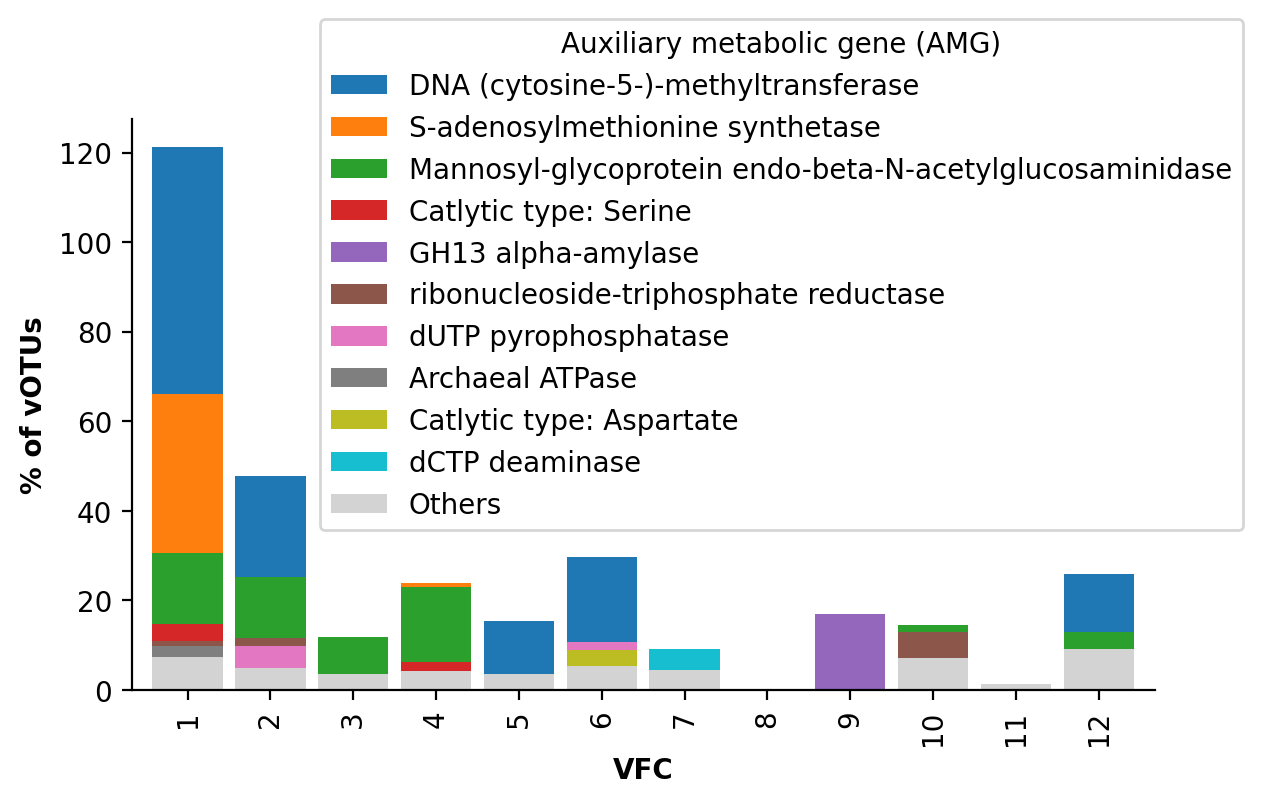

In [17]:
colors = ([f'C{i}' for i in range(len(amg_cols)-1)] + ['lightgrey'])[::-1]

fig, ax = plt.subplots(figsize=(6.4, 4.2), dpi=200)

df_pct.plot(
    kind='bar',
    stacked=True,
    width=0.85,
    color=colors,
    linewidth=0,
    ax=ax
)

# Annotate outlier VFCs
for i, vfc in enumerate(topvfcs):
    if vfc in vfcs_highamg:
        top = df_pct.iloc[i].sum()
        ax.text(
            i,
            top,
            "*",
            ha='center',
            va='bottom',
            fontsize=10,
            color='black'
        )


plt.xlabel("VFC", fontweight='bold')
plt.ylabel("% of vOTUs", fontweight='bold')
plt.xticks(range(len(topvfcs)), topvfcs)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title="Auxiliary metabolic gene (AMG)", bbox_to_anchor=(1.1, 1.2), loc="upper right")

plt.tight_layout()
sns.despine()

### Supplementary Fig. 31B: VFC 1 likely carries a CRISPR anti-defense system

In [18]:
v_pr = pd.read_excel('../data/Supplementary_Data_6_virus-host_associations.xlsx', sheet_name='prophage', usecols=['votu_id']).votu_id.unique()
v_sp = pd.read_excel('../data/Supplementary_Data_6_virus-host_associations.xlsx', sheet_name='spacer matching', usecols=['votu_id']).votu_id.unique()
v_hc = pd.read_excel('../data/Supplementary_Data_6_virus-host_associations.xlsx', sheet_name='Hi-C', usecols=['votu_id']).votu_id.unique()

df_v['has_prhost'] = df_v.votu_id.isin(v_pr).astype(int)
df_v['has_sphost'] = df_v.votu_id.isin(v_sp).astype(int)
df_v['has_hchost'] = df_v.votu_id.isin(v_hc).astype(int)

df_v_topvfc = df_v[df_v.VFC.isin(topvfcs)]

C:\Users\chenhr\AppData\Local\Temp\ipykernel_45388\331496081.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(topvfcs)


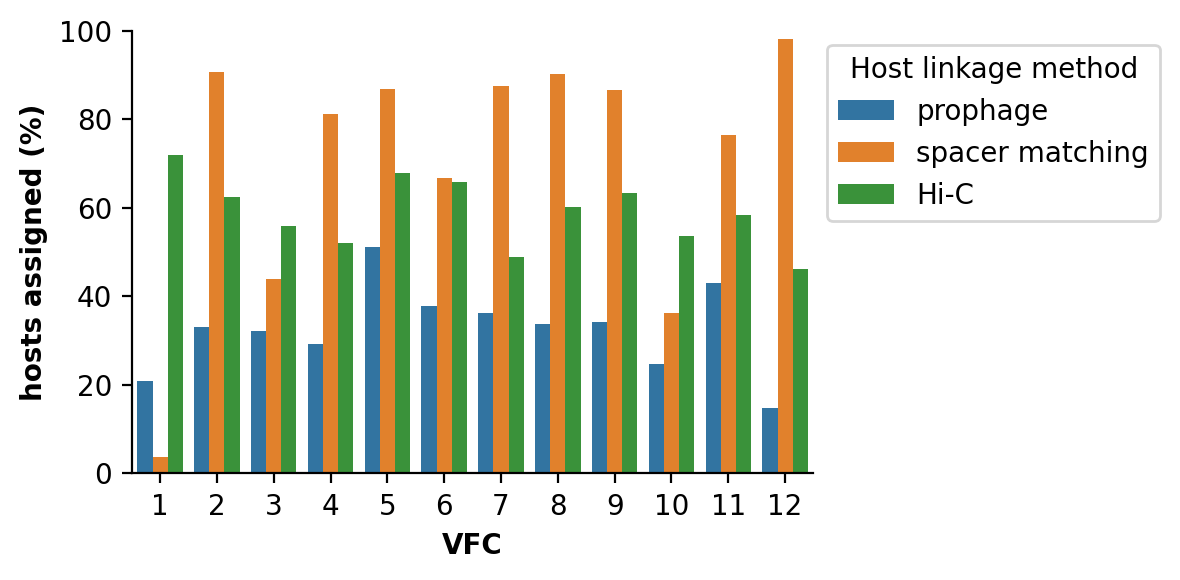

In [19]:
cols = ["has_prhost", "has_sphost", "has_hchost"]

pct_df = (
    df_v_topvfc
    .groupby("VFC", as_index=False)[cols]
    .apply(lambda x: x.mean()*100)
)

plot_df = pct_df.melt(id_vars="VFC", 
                      value_vars=cols,
                      var_name="host_type",
                      value_name="percent")

plot_df["VFC"] = pd.Categorical(plot_df["VFC"],
                                categories=topvfcs,
                                ordered=True)

plot_df["host_type"] = plot_df["host_type"].map({
    "has_prhost": "prophage",
    "has_sphost": "spacer matching",
    "has_hchost": "Hi-C"
})

fig, ax = plt.subplots(figsize=(6,3), dpi=200)

sns.barplot(data=plot_df, x="VFC", y="percent", hue="host_type", order=topvfcs)

plt.ylabel("hosts assigned (%)", fontweight='bold')
plt.xlabel("VFC", fontweight='bold')
plt.ylim(0,100)
ax.set_xticklabels(topvfcs)
plt.legend(title="Host linkage method", bbox_to_anchor=(1,1), loc='upper left')

sns.despine()
plt.tight_layout()